In [30]:
#import packages 
import numpy as np
import pandas as pd

In [31]:
#create the dataframe
df=pd.read_excel("ApexPlanet_DataAnalytics_Dataset.xlsx")

In [32]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [33]:
#Data familiarization
df.dtypes

Order_ID          object
Order_Date        object
Customer_ID       object
Customer_Name     object
Age              float64
Gender            object
City              object
Product           object
Category          object
Quantity           int64
Unit_Price       float64
Total_Sales      float64
dtype: object

In [34]:
df['Product'].unique()

array(['Rice', 'Book', 'Mobile', 'Laptop', 'Shoes', 'Chair'], dtype=object)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB


In [36]:
#Identifing the missing values
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Name     0
Age              20
Gender            0
City             13
Product           0
Category          0
Quantity          0
Unit_Price        0
Total_Sales       0
dtype: int64

In [37]:
#identifing the duplicated values
print(df.duplicated().sum())
df[df.duplicated()]

0


,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales


In [38]:
#checking unique values for features which can possible has formatting errors
print(df['Gender'].unique())
print(df['City'].unique())
print(df['Category'].unique())

['Female' 'Male']
['Bengaluru' 'Kolkata' 'Hyderabad' 'Patna' 'Mumbai' 'Delhi' 'Gaya' 'Pune'
 nan]
['Grocery' 'Education' 'Electronics' 'Fashion' 'Furniture']


In city column has one nan values

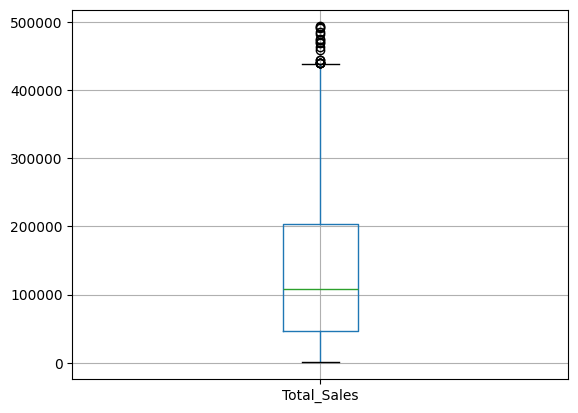

In [39]:
import matplotlib.pyplot as plt

df.boxplot(column='Total_Sales')
plt.show()

Total_Sales has some outliers

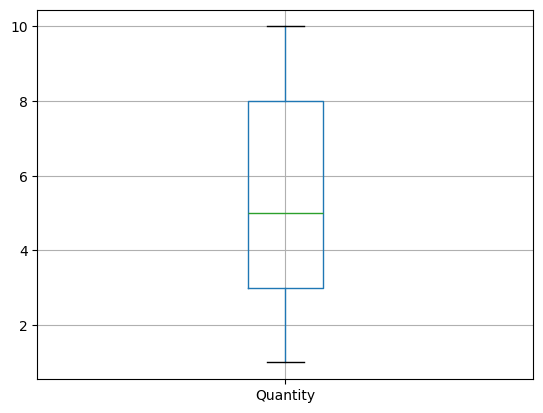

In [40]:
df.boxplot(column='Quantity')
plt.show()

This feature has no outliers

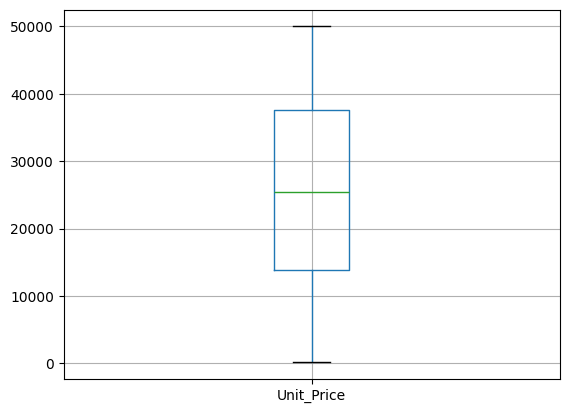

In [41]:
df.boxplot(column='Unit_Price')
plt.show()

This feature has no outliers

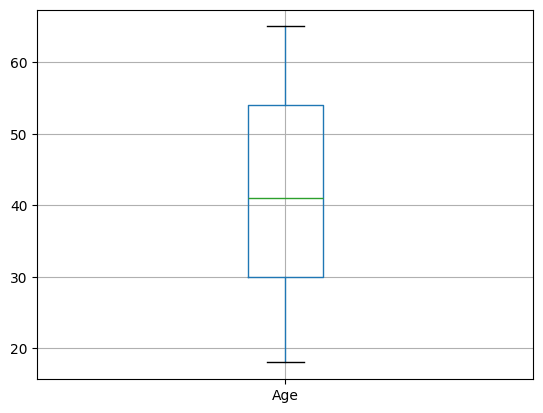

In [42]:
df.boxplot(column='Age')
plt.show()

This feature has no outliers

Initial data profiling was performed to assess data quality. The dataset was examined for missing values, duplicate records, inconsistent formatting, and outliers. Missing values were identified in demographic fields, duplicate records were checked to prevent double-counting of sales, categorical variables were reviewed for formatting inconsistencies, and numerical features such as Quantity, Unit_Price, and Total_Sales were analyzed for outliers. These findings will guide the data cleaning and transformation phase.

In [43]:
# Fill Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())
# Fill City with mode
df['City'] = df['City'].fillna(df['City'].mode()[0])

In [44]:
df.isnull().sum()

Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Age              0
Gender           0
City             0
Product          0
Category         0
Quantity         0
Unit_Price       0
Total_Sales      0
dtype: int64

missing values are filled with mean or median or mode

In [45]:
#there is no duplicates i data frame [df.drop_duplicates(inplace=True)]
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [46]:

#Standardize Text Formatting
text_cols = ['Gender', 'City', 'Product', 'Category']

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

In [47]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [48]:
#Standardize Date Format
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Format as YYYY-MM-DD
df['Order_Date'] = df['Order_Date'].dt.strftime('%Y-%m-%d')

In [49]:
#Categorize Free-Text Fields
bins = [0, 25, 35, 50, 100]
labels = ['Young Adult', 'Adult', 'Middle Age', 'Senior']

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [50]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Age_Group
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,Adult
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,Senior
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,Senior
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,Senior
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,Middle Age


In [51]:
#Feature Engineering
#Extract Month
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Month'] = df['Order_Date'].dt.month_name()
#Extract Quarter
df['Quarter'] = df['Order_Date'].dt.quarter
#Extract Day Name
df['Day_Name'] = df['Order_Date'].dt.day_name()
#Average Selling Price Check
df['Avg_Selling_Price'] = (
    df['Total_Sales'] / df['Quantity']
)
#High Value Customer Flag
df['High_Value_Customer'] = np.where(
    df['Total_Sales'] > 100000,
    'Yes',
    'No'
)

In [52]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Age_Group,Month,Quarter,Day_Name,Avg_Selling_Price,High_Value_Customer
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,Adult,February,1,Tuesday,2829.77,No
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,Senior,October,4,Tuesday,27906.16,Yes
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,Senior,May,2,Tuesday,37491.06,Yes
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,Senior,December,4,Tuesday,28541.36,Yes
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,Middle Age,November,4,Thursday,14036.59,Yes


In [53]:
#Outlier Detection (IQR Method)
Q1 = df['Total_Sales'].quantile(0.25)
Q3 = df['Total_Sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Total_Sales'] < lower) |
    (df['Total_Sales'] > upper)
]

print("Outliers Found:", len(outliers))

Outliers Found: 19


In [54]:
#Remove Outliers:

df = df[
    (df['Total_Sales'] >= lower) &
    (df['Total_Sales'] <= upper)
]

In [55]:
df.shape

(981, 18)

In [56]:
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 0 to 999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order_ID             981 non-null    object        
 1   Order_Date           981 non-null    datetime64[ns]
 2   Customer_ID          981 non-null    object        
 3   Customer_Name        981 non-null    object        
 4   Age                  981 non-null    float64       
 5   Gender               981 non-null    object        
 6   City                 981 non-null    object        
 7   Product              981 non-null    object        
 8   Category             981 non-null    object        
 9   Quantity             981 non-null    int64         
 10  Unit_Price           981 non-null    float64       
 11  Total_Sales          981 non-null    float64       
 12  Age_Group            981 non-null    category      
 13  Month                981 non-null    obj

In [57]:
df.to_csv(
    "sales_data_cleaned.csv",
    index=False
)

print("Analysis-ready dataset saved successfully.")

Analysis-ready dataset saved successfully.
